In [1]:
# Stop warnings
import warnings
warnings.filterwarnings("ignore")

# Imports
import os
import cv2
import sys
import glob
import time
import json
import copy
import cortex
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from scipy.spatial import Delaunay

# Personal imports
sys.path.append("{}/../../analysis_code/utils".format(os.getcwd()))
# from plot_utils import *
from settings_utils import load_settings
from pycortex_utils import draw_cortex, set_pycortex_config_file, load_surface_pycortex, create_colormap, get_rois
from surface_utils import load_surface

In [2]:
# Directories
main_dir = '/Users/uriel/disks/meso_shared'
project_dir = 'amblyo7T_prf'

In [3]:
# Load settings
base_dir = os.path.abspath(os.path.join(os.getcwd(), "../../"))
settings_path = os.path.join(base_dir, project_dir, "settings.yml")
prf_settings_path = os.path.join(base_dir, project_dir, "prf-analysis.yml")
figure_settings_path = os.path.join(base_dir, project_dir, "figure-settings.yml")

settings = load_settings([settings_path, prf_settings_path, figure_settings_path])
analysis_info = settings[0]

In [4]:
# Set pycortex db and colormaps
cortex_dir = "{}/{}/derivatives/pp_data/cortex".format(main_dir, project_dir)
set_pycortex_config_file(cortex_dir)

# Webgl port
port_num = 25000

In [5]:
# Settings
subject = 'sub-03'
pycortex_subject = 'sub-03'
format_ = 'fsnative'
extension = 'func.gii'
rsq2use = 'prf_loo_rsq'
avg_method = 'loo-avg'

rois_method_format = 'rois-group-mmp'
overlay_fn = "{}/db/{}/overlays_{}.svg".format(cortex_dir, pycortex_subject, rois_method_format )


# Bold signal

In [6]:
# Directories
# bold_dir = '/Users/uriel/disks/meso_shared/amblyo7T_prf/derivatives/fmriprep/fmriprep/{}/ses-01/func'.format(subject)
# bold_fn_lh = '{}/{}_ses-01_task-BarsRightEye_run-01_hemi-L_space-fsnative_bold.func.gii'.format(bold_dir, subject)
# bold_fn_rh = '{}/{}_ses-01_task-BarsRightEye_run-01_hemi-R_space-fsnative_bold.func.gii'.format(bold_dir, subject)

bold_dir = '/Users/uriel/disks/meso_shared/amblyo7T_prf/derivatives/pp_data/sub-03/fsnative/func/fmriprep_dct_z-score'
bold_fn_lh = '{}/{}_ses-01_task-BarsLeftEye_run-01_hemi-L_space-fsnative_fmriprep_dct_z-score_bold.func.gii'.format(bold_dir, subject)
bold_fn_rh = '{}/{}_ses-01_task-BarsLeftEye_run-01_hemi-R_space-fsnative_fmriprep_dct_z-score_bold.func.gii'.format(bold_dir, subject)

# Load bold 
results = load_surface_pycortex(L_fn=bold_fn_lh, R_fn=bold_fn_rh)
bold_data = results['data_concat']

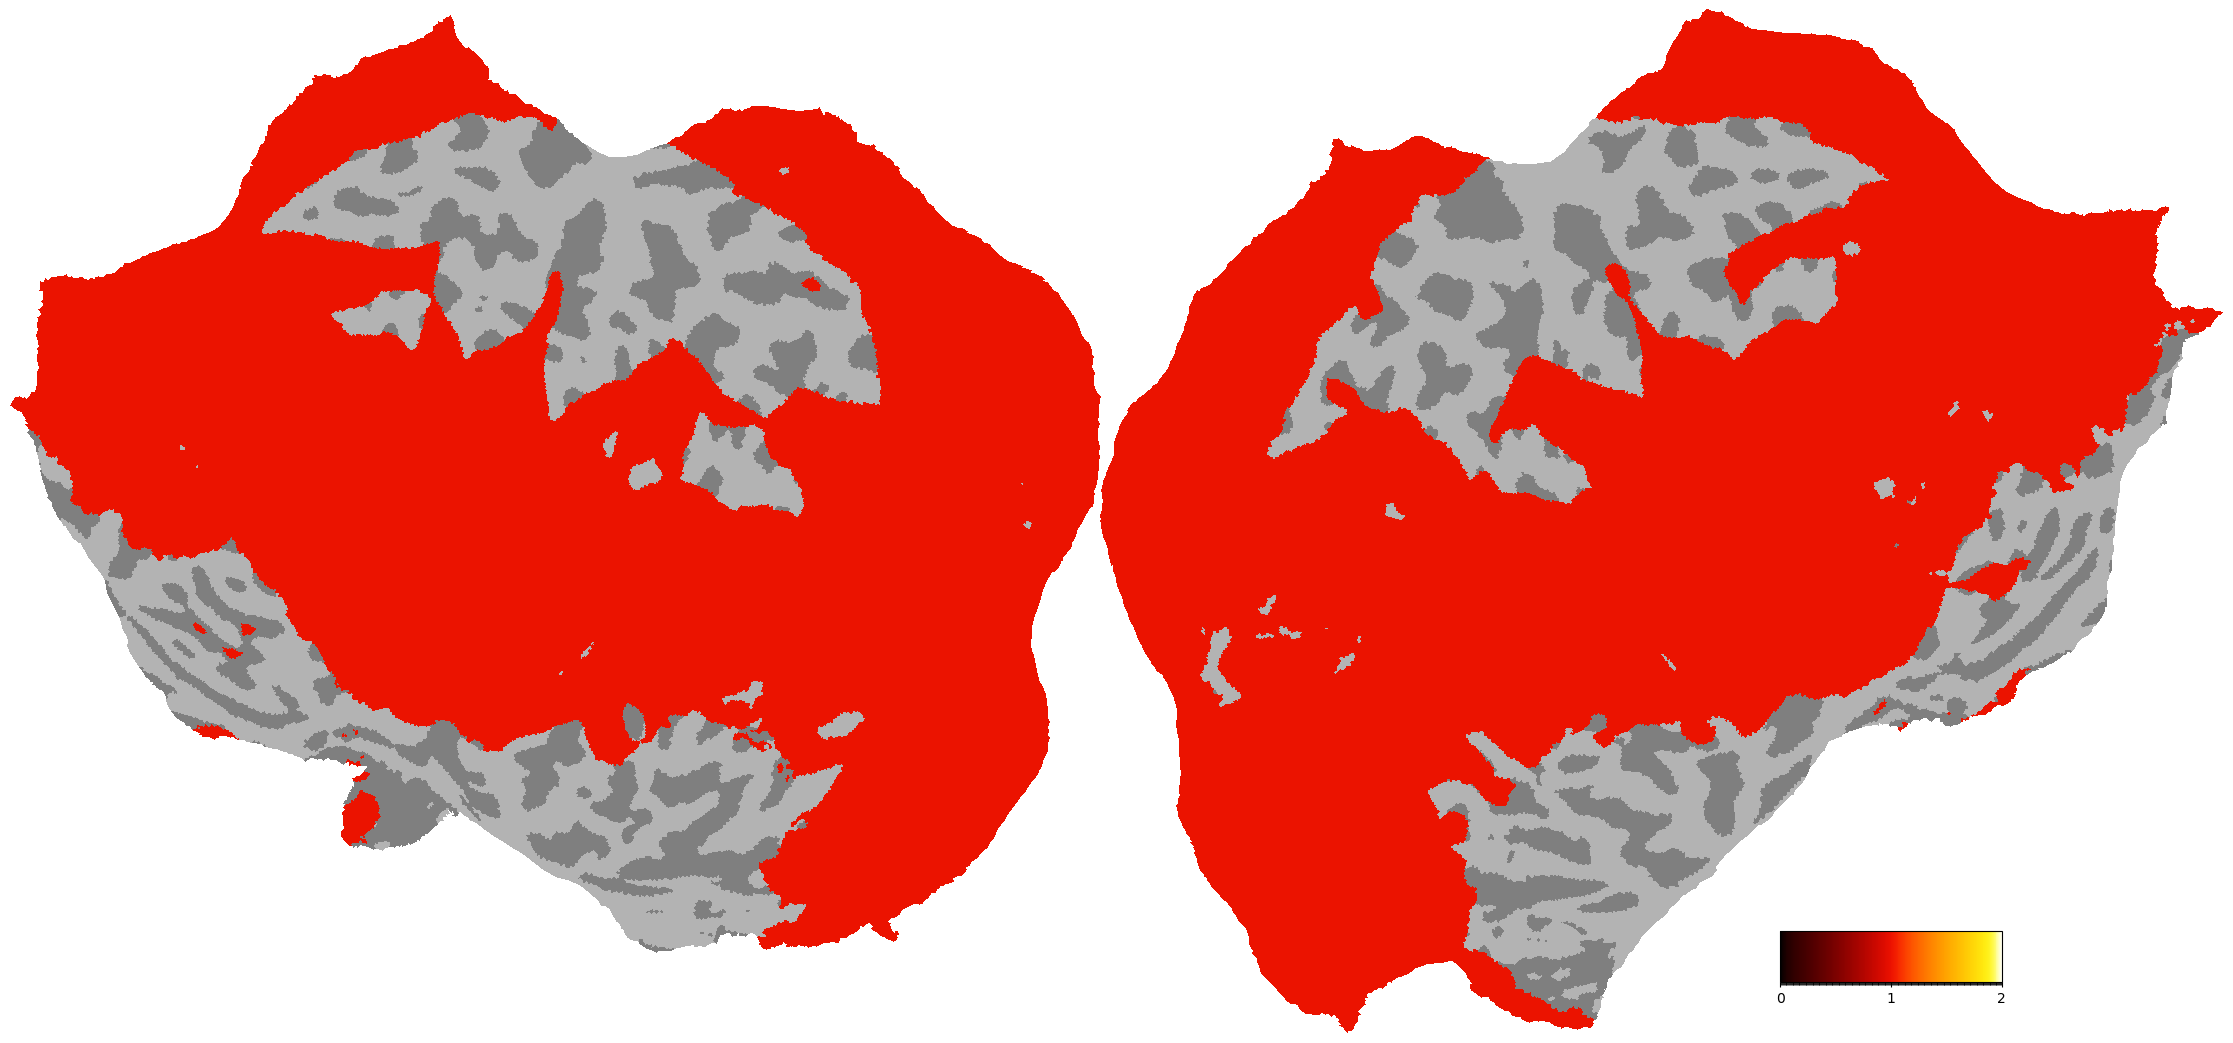

In [18]:
# Polar angle

vert_num = 117

alpha = (~np.any(np.isnan(bold_data), axis=0)).astype(int)

# variance_threshold = 1000
# alpha = (np.var(bold_data, axis=0) > variance_threshold).astype(int)

data = bold_data[vert_num, :]
data_min = 0 #data.nanmin() 
data_max = 2 #data.nanmax() 


param_bold = {'data': alpha, 
              'subject': pycortex_subject,
               'cmap': 'fire', 
               'alpha': alpha, 
               'vmin': data_min, 
               'vmax': data_max, 
               # 'cmap_steps': cmap_steps, 
               'cortex_type': 'VertexRGB',
               'cbar': 'discrete', 
               # 'col_offset': col_offset, 
               'description': 'bold', 
               'curv_brightness': 0.6, 
               'curv_contrast': 0.2, 
               'add_roi': False, 
               'with_labels': True}

volume_bold = draw_cortex(**param_bold)
inflated_dir = '/Users/uriel/Library/CloudStorage/Dropbox/amblyo_prf/figures/material/pycortex/brain'
plt.savefig('{}/flat_bold.png'.format(inflated_dir))

In [15]:
overlay_fn = '/Users/uriel/disks/meso_shared/RetinoMaps/derivatives/pp_data/cortex/db/sub-170k_old/overlays_roi.svg'
port_num = port_num + 1

# Remome overlays_visible=('sulci','roi'), to have borders 
print("Go to (in 5 s...): http://localhost:{}/".format(port_num))
handle = cortex.webgl.show(data=volume_bold,
                           recache=True,
                           port=port_num,
                           overlays_visible=('rois',),
                           labels_visible=(),
                           # overlay_file = overlay_fn,
                          )

Go to (in 5 s...): http://localhost:25002/
Generating new ctm file...
wm
wm
inflated
inflated
Started server on port 25002


In [16]:
# inflated
inflated_general = {'camera.azimuth':138,
                    'camera.altitude':78,
                    'camera.radius':604,
                    'surface.{subject}.unfold':0.5,
                    'surface.{subject}.pivot':0,
                    'surface.{subject}.left':True,
                    'surface.{subject}.right':False,
                    'surface.{subject}.depth':1,
                    'surface.{subject}.specularity':0,
                    'surface.{subject}.layers':4,
                    'surface.{subject}.dither':False,
                    'surface.{subject}.colorbar':False,
                    'surface.{subject}.sampler':'nearest',
                    'surface.{subject}.curvature.brightness':0.1,
                    'surface.{subject}.curvature.contrast':0.8,
                    'surface.{subject}.curvature.smoothness':1}
handle._set_view(**inflated_general)
time.sleep(5)

inflated_dir = '/Users/uriel/Library/CloudStorage/Dropbox/amblyo_prf/figures/material/pycortex/brain'
im1 = handle.getImage('{}/bold_left.png'.format(inflated_dir),size = (3000, 3000))


In [17]:
# inflated
inflated_general = {'camera.azimuth':99,
                    'camera.altitude':96,
                    'camera.radius':604,
                    'surface.{subject}.unfold':0.5,
                    'surface.{subject}.pivot':0,
                    'surface.{subject}.left':False,
                    'surface.{subject}.right':True,
                    'surface.{subject}.depth':1,
                    'surface.{subject}.specularity':0,
                    'surface.{subject}.layers':4,
                    'surface.{subject}.dither':False,
                    'surface.{subject}.colorbar':False,
                    'surface.{subject}.sampler':'nearest',
                    'surface.{subject}.curvature.brightness':0.1,
                    'surface.{subject}.curvature.contrast':0.8,
                    'surface.{subject}.curvature.smoothness':1}
handle._set_view(**inflated_general)
time.sleep(5)

inflated_dir = '/Users/uriel/Library/CloudStorage/Dropbox/amblyo_prf/figures/material/pycortex/brain'
im1 = handle.getImage('{}/bold_right.png'.format(inflated_dir),size = (3000, 3000))


# Rois

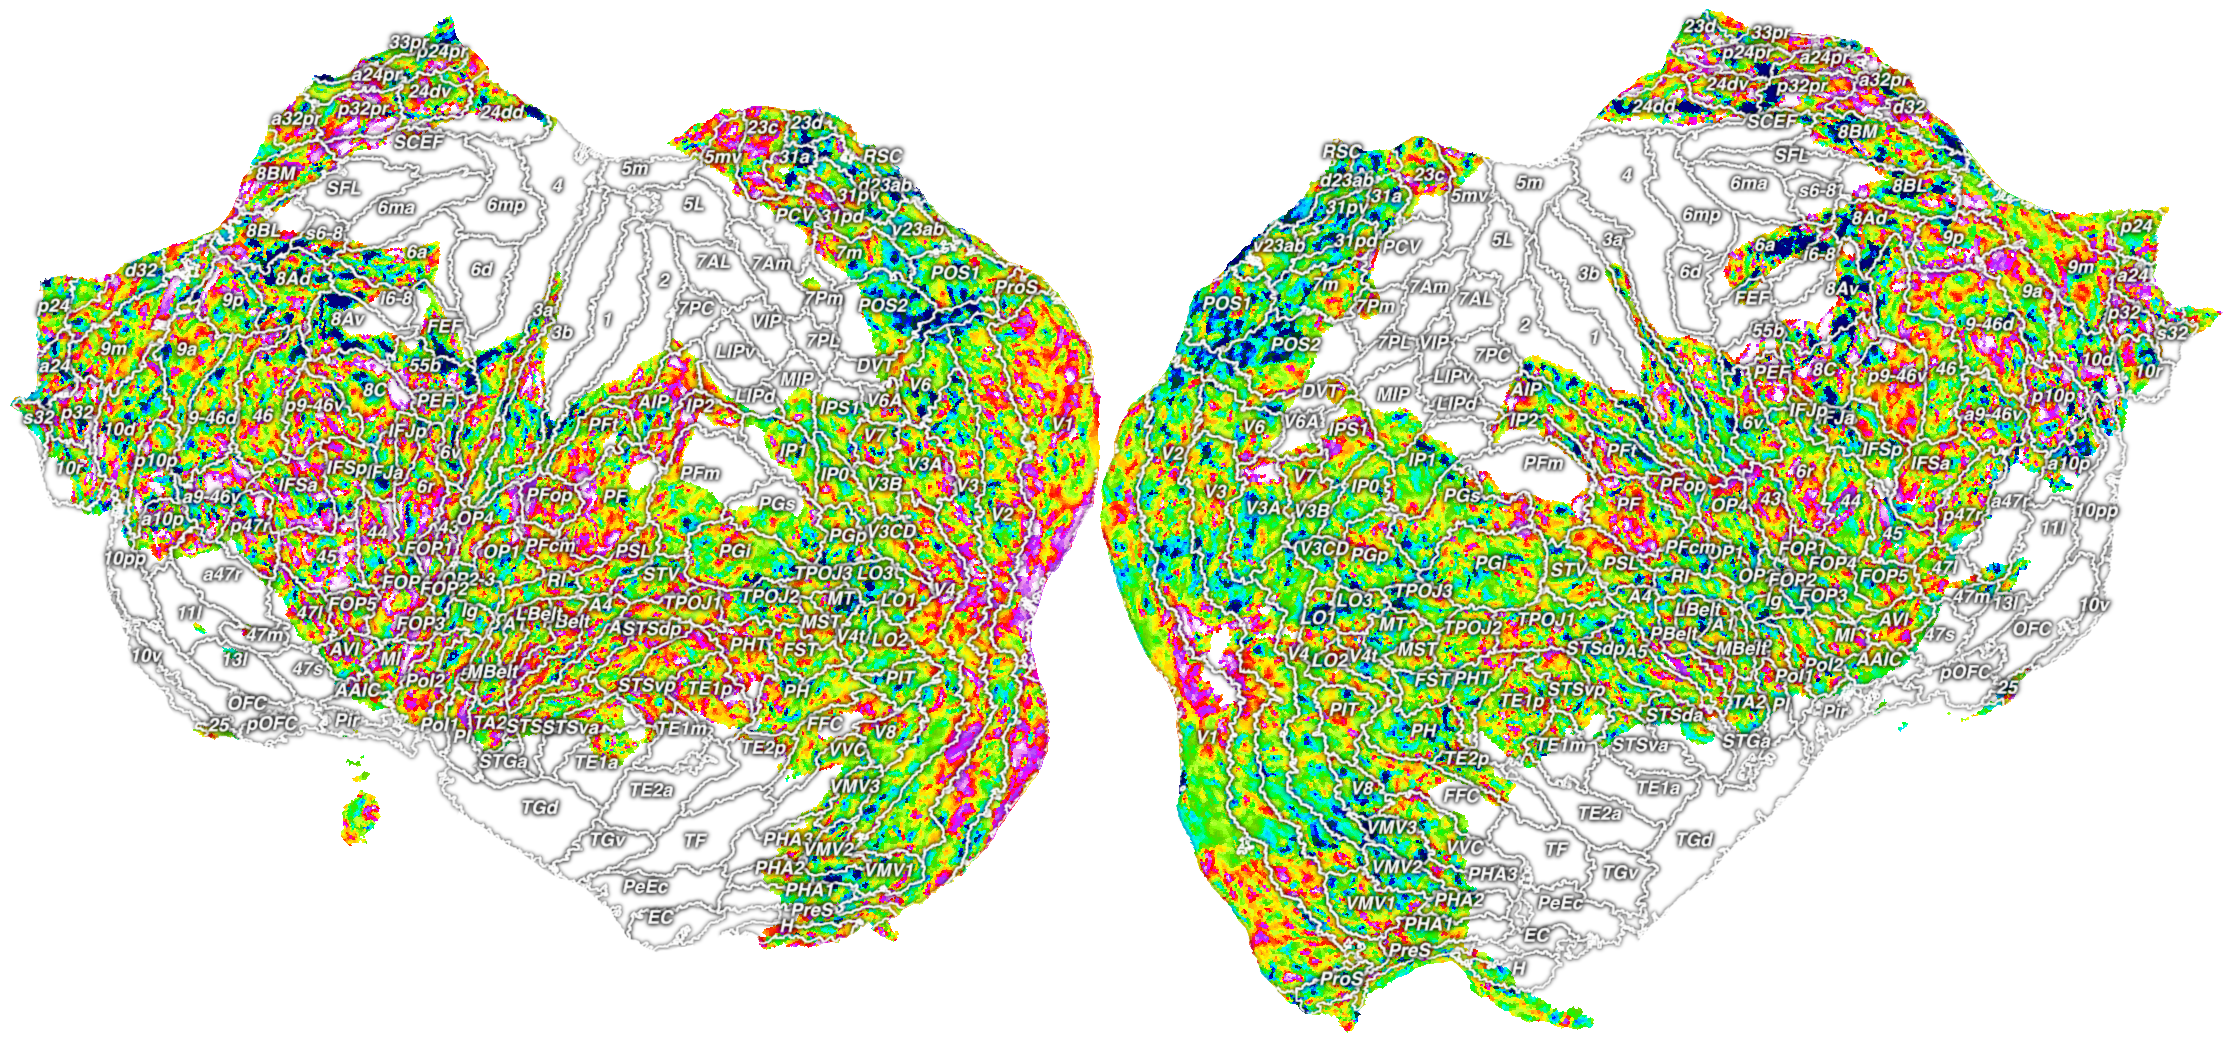

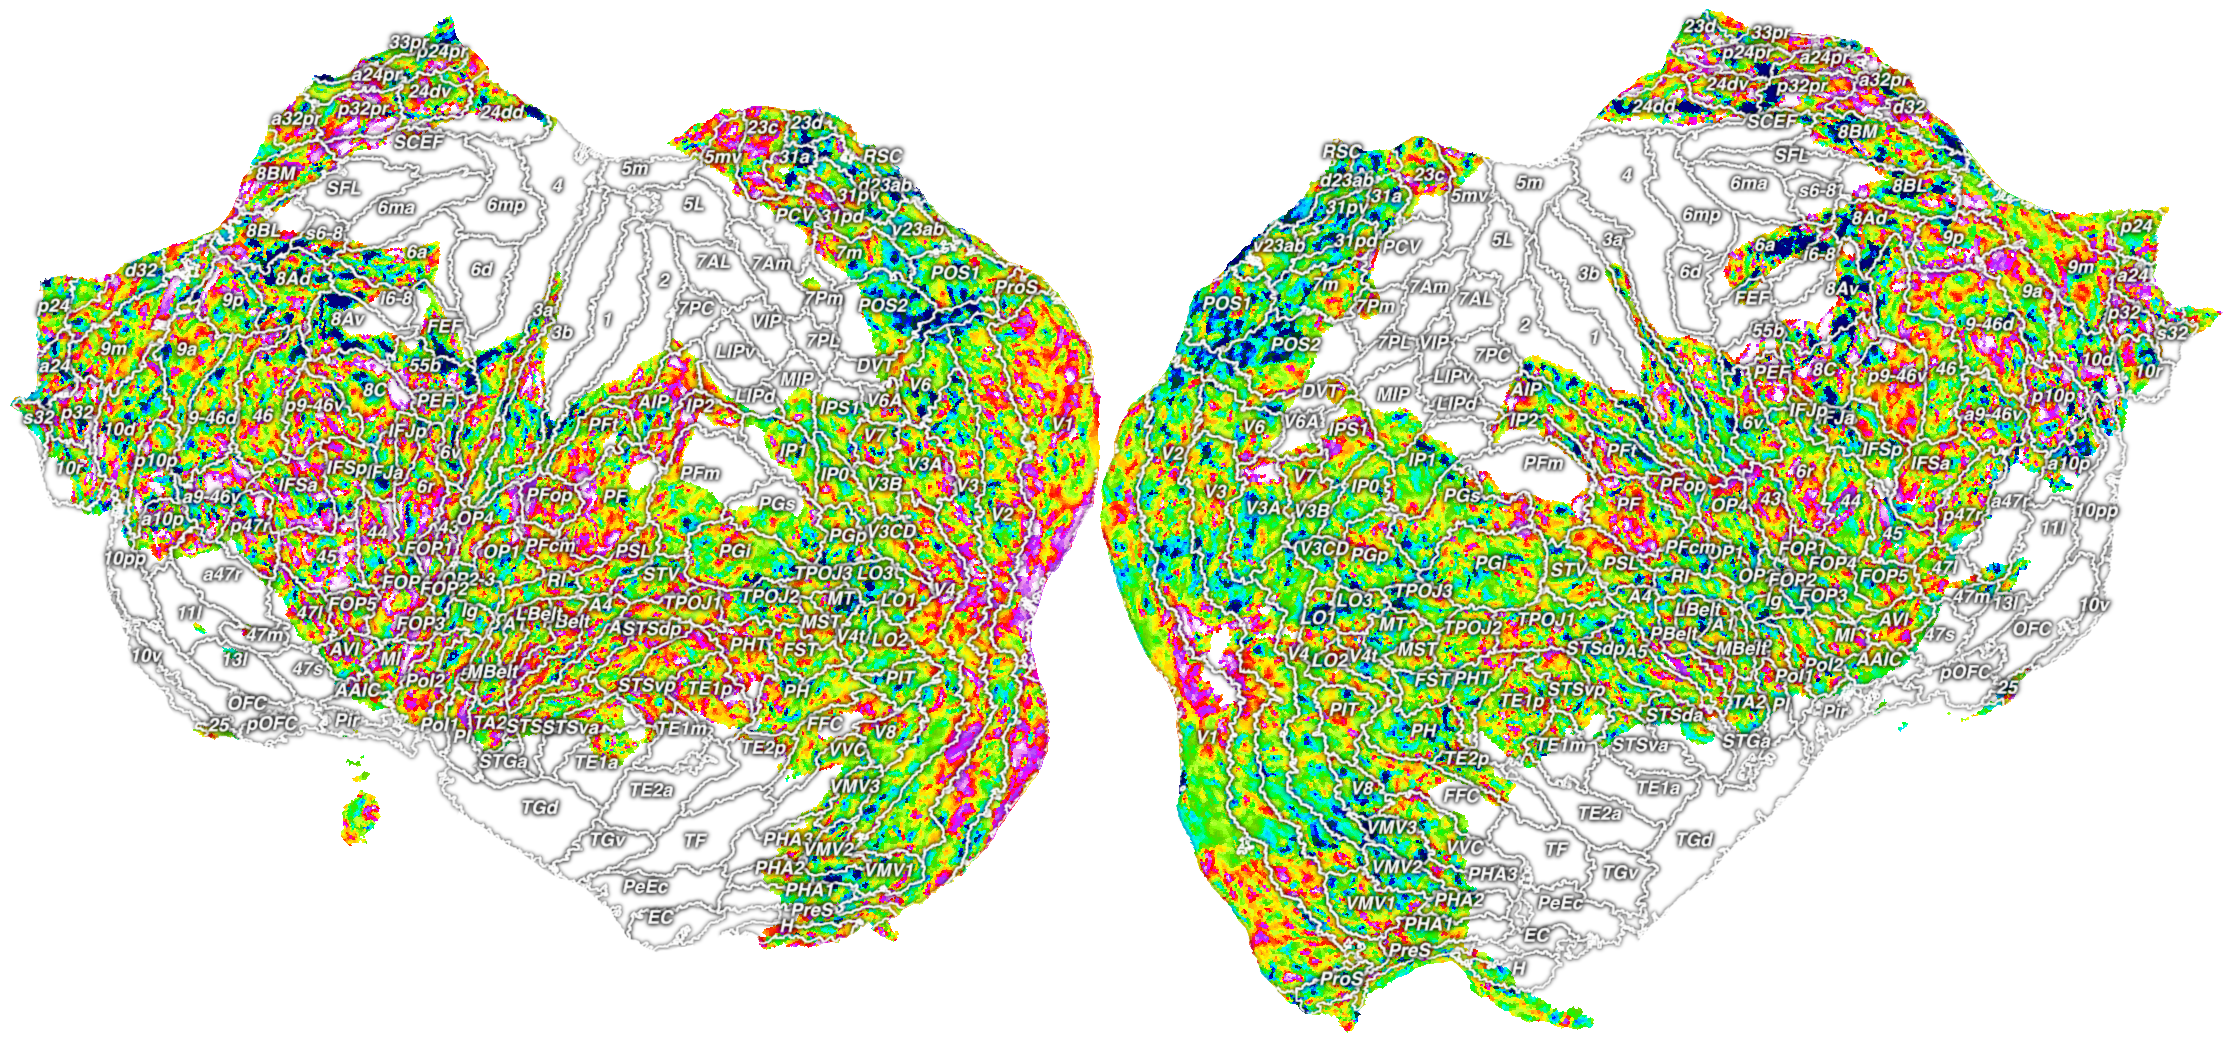

In [27]:
vertex_data = cortex.Vertex(data, pycortex_subject, cmap='gist_ncar')


# cortex.quickshow()

cortex.quickshow(vertex_data, with_colorbar=False, overlay_file='/Users/uriel/disks/meso_shared/amblyo7T_prf/derivatives/pp_data/cortex/db/sub-03/overlays_rois-mmp.svg')
# plt.title("MMP atlas", fontsize=25)
# plt.savefig('/Users/uriel/Downloads/mmp_atlas.pdf')
# plt.show()